In [2]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "1ukMf_11d37nWJ0fdzBX0lH_JRoqHoMRJCDnLw1I0mTQ"
GID = "602969641"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['State', 'Sex', 'Age', 'Color', 'Years_of_study', 'Income', 'Height']


,State,Sex,Age,Color,Years_of_study,Income,Height
0,Rondônia,Male,23,Brown,11,800,1.6
1,Rondônia,Female,23,White,11,1150,1.74
2,Rondônia,Female,35,Brown,14,880,1.76
3,Rondônia,Male,46,White,5,3500,1.78
4,Rondônia,Female,47,Brown,8,150,1.69


In [3]:
FEATURES = ["Age", "Years_of_study", "Income", "Height"]

TARGET = "State"            # coluna F (classe)

for col in FEATURES :
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())


Distribuição do target:
State
são paulo              8544
minas gerais           7686
rio grande do sul      6322
bahia                  5717
rio de janeiro         5556
pará                   4449
paraná                 4356
pernambuco             3820
goiás                  3478
ceará                  3359
santa catarina         2275
amazonas               2206
distrito federal       2054
mato grosso            1800
maranhão               1787
rondônia               1537
espírito santo         1511
mato grosso do sul     1440
tocantins              1306
sergipe                1287
paraíba                1274
piauí                  1211
rio grande do norte     973
acre                    937
alagoas                 903
roraima                 540
amapá                   512
Name: count, dtype: int64


In [4]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['acre', 'alagoas', 'amapá', 'amazonas', 'bahia', 'ceará', 'distrito federal', 'espírito santo', 'goiás', 'maranhão', 'mato grosso', 'mato grosso do sul', 'minas gerais', 'paraná', 'paraíba', 'pará', 'pernambuco', 'piauí', 'rio de janeiro', 'rio grande do norte', 'rio grande do sul', 'rondônia', 'roraima', 'santa catarina', 'sergipe', 'são paulo', 'tocantins']
Total linhas válidas: 76840


In [5]:
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))


Treino: 61472 | Teste: 15368


In [6]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=76840) ===


,qtd,%
State,,
são paulo,8544,11.1
minas gerais,7686,10.0
rio grande do sul,6322,8.2
bahia,5717,7.4
rio de janeiro,5556,7.2
pará,4449,5.8
paraná,4356,5.7
pernambuco,3820,5.0
goiás,3478,4.5



=== Treino (n=61472) ===


,qtd,%
State,,
são paulo,6791,11.0
minas gerais,6107,9.9
rio grande do sul,5106,8.3
bahia,4537,7.4
rio de janeiro,4425,7.2
pará,3528,5.7
paraná,3497,5.7
pernambuco,3052,5.0
goiás,2795,4.5



=== Teste (n=15368) ===


,qtd,%
State,,
são paulo,1753,11.4
minas gerais,1579,10.3
rio grande do sul,1216,7.9
bahia,1180,7.7
rio de janeiro,1131,7.4
pará,921,6.0
paraná,859,5.6
pernambuco,768,5.0
goiás,683,4.4


In [7]:
# Modelo KNN
K = 5
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [8]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))


Features usadas: ['Age', 'Years_of_study', 'Income', 'Height']
Acurácia: 0.07847475273295158

Relatório:
                     precision    recall  f1-score   support

               acre       0.02      0.02      0.02       176
            alagoas       0.02      0.02      0.02       171
              amapá       0.00      0.00      0.00       108
           amazonas       0.01      0.01      0.01       440
              bahia       0.10      0.12      0.11      1180
              ceará       0.05      0.05      0.05       643
   distrito federal       0.05      0.06      0.05       380
     espírito santo       0.03      0.03      0.03       327
              goiás       0.06      0.06      0.06       683
           maranhão       0.05      0.05      0.05       361
        mato grosso       0.03      0.03      0.03       352
 mato grosso do sul       0.02      0.02      0.02       275
       minas gerais       0.13      0.14      0.13      1579
             paraná       0.07      0.0

In [9]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[FEATURES + [TARGET, "classe_prevista"]])

,Age,Years_of_study,Income,Height,State,classe_prevista
0,32,15,5000,1.71,paraná,minas gerais
1,49,11,500,1.63,pará,rio grande do sul
2,53,11,4500,1.85,rio grande do sul,rio grande do sul
3,59,8,1650,1.66,rio de janeiro,paraná
4,48,11,800,1.73,bahia,pará
...,...,...,...,...,...,...
15363,29,15,2200,1.76,paraná,são paulo
15364,40,6,400,1.60,pará,pernambuco
15365,35,13,3000,1.76,rio grande do sul,rio de janeiro
15366,46,15,5000,1.71,são paulo,rio de janeiro



=== Árvore de decisão ===
Features usadas: ['Age', 'Years_of_study', 'Income', 'Height']
Acurácia: 0.14165799062988027

Relatório:
                     precision    recall  f1-score   support

               acre       0.00      0.00      0.00       176
            alagoas       0.00      0.00      0.00       171
              amapá       0.00      0.00      0.00       108
           amazonas       0.00      0.00      0.00       440
              bahia       0.13      0.37      0.20      1180
              ceará       0.00      0.00      0.00       643
   distrito federal       0.00      0.00      0.00       380
     espírito santo       0.00      0.00      0.00       327
              goiás       0.00      0.00      0.00       683
           maranhão       0.00      0.00      0.00       361
        mato grosso       0.00      0.00      0.00       352
 mato grosso do sul       0.00      0.00      0.00       275
       minas gerais       0.12      0.15      0.13      1579
             

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Age,Years_of_study,Income,Height,State,classe_prevista_arvore
0,32,15,5000,1.71,paraná,são paulo
1,49,11,500,1.63,pará,minas gerais
2,53,11,4500,1.85,rio grande do sul,são paulo
3,59,8,1650,1.66,rio de janeiro,são paulo
4,48,11,800,1.73,bahia,minas gerais
...,...,...,...,...,...,...
15363,29,15,2200,1.76,paraná,são paulo
15364,40,6,400,1.60,pará,bahia
15365,35,13,3000,1.76,rio grande do sul,são paulo
15366,46,15,5000,1.71,são paulo,são paulo


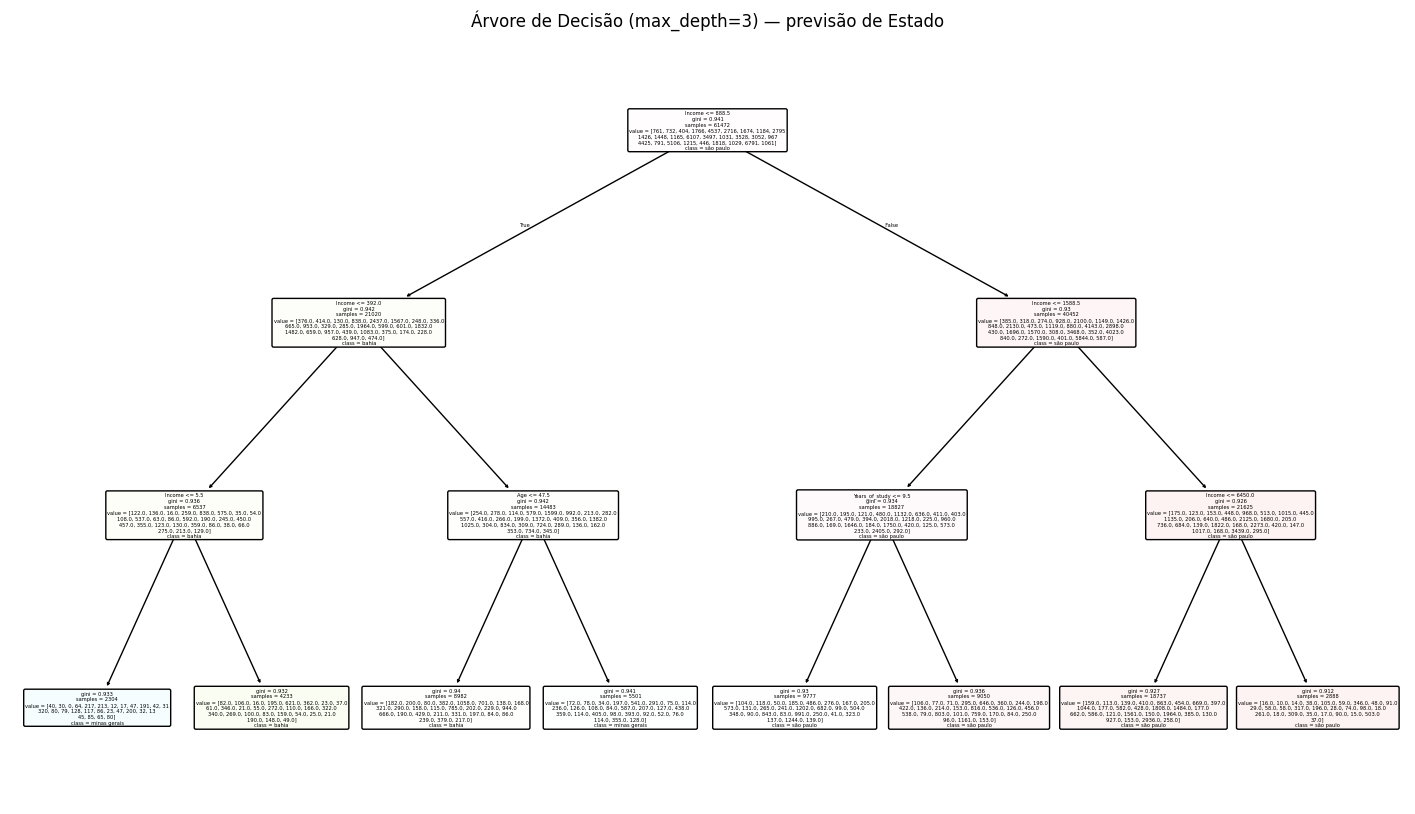

In [10]:


# ========= Árvore de decisão (usando as MESMAS variáveis do seu Colab) =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste (sem mudar sua tabela do KNN, usa outra coluna)
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de Estado")
plt.show()